## Benchmarks

In [1]:
import sph_cupy
import sph # baseline
import sph_multiprocessing
import sph_core

[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
------------
[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
----------
[[ 0.20262504  0.12708993  0.03936404]
 [ 0.58161663  0.04282153 -0.12876747]
 [ 0.11285734  0.29377433 -0.11445015]
 ...
 [-0.59835171 -0.07789294 -0.05228875]
 [-0.50338322  0.15863895 -0.28661348]
 [ 0.23923893  0.16312656  0.51541201]]
mp:
True
True
cp:
False
False
cython:
False
False


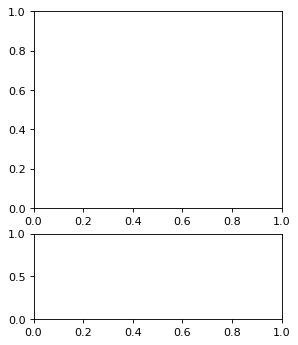

In [ ]:
# Vailidation
import numpy as np

N = 400

pos, vel = sph.main(400)
mp_pos, mp_vel = sph_multiprocessing.main(400)
cp_pos, cp_vel = sph_cupy.main(400)
cython_pos, cython_vel = sph_core.run_sph_cython(400)

print(pos)
print("------------")
print(cp_pos)
print("----------")
print(cython_pos)

print("mp:")
print(np.allclose(pos, mp_pos))
print(np.allclose(vel, mp_vel))
print("cp:")
print(np.allclose(pos, cp_pos))
print(np.allclose(vel, cp_vel))
print("cython:")
print(np.allclose(pos, cython_pos))
print(np.allclose(vel, cython_vel))



In [ ]:
import matplotlib.pyplot as plt

def benchmark(funcs, Ns):
    benchmark_data = {}
    for func in funcs:
        ts_avg = []
        for n in Ns:
            t = %timeit -o func(n)
            ts_avg.append(t.average)
        
        benchmark_data[func.__module__] = ts_avg
        
    return benchmark_data

def plot_benchmarks(benchmark_data, Ns):
    plt.close("all")
    plt.title("Benchmarks")
    for t in benchmark_data:
        plt.plot(Ns, benchmark_data[t], marker='o', label=t)
        plt.xlabel("Number of particles")
        plt.legend()
        plt.grid(True)
        plt.ylabel("Average runtime")
    plt.show()


In [ ]:
import time

t1 = time.time()
sph.main(1000)
print(f"sph time: {time.time() - t1}")

t1 = time.time()
sph_multiprocessing.main(1000)
print(f"sph mp time: {time.time() - t1}")

In [ ]:
funcs = [sph_cupy.main, sph.main, sph_multiprocessing.main, sph_core.run_sph_cython]
Ns = [400, 600, 800, 1000, 2000]

benchmarks = benchmark(funcs, Ns)
plot_benchmarks(benchmarks, Ns)